# Stage 5: LightGBM Model Training with Class Imbalance Weighting

## Runtime Drivers & Dependencies

In [1]:
!pip uninstall -y -q datasets
!pip install -q -U s3fs boto3 botocore pyarrow lightgbm scikit-learn rapidfuzz
print("✅ LightGBM & S3 Drivers ready!")

✅ LightGBM & S3 Drivers ready!


## AWS Credentials & S3 Storage Configuration

In [2]:
import os
import io
import gc
import joblib
import pandas as pd
import numpy as np
import lightgbm as lgb
from google.colab import userdata
import matplotlib.pyplot as plt

# 1. AWS Credentials
AWS_ACCESS_KEY_ID = userdata.get("AWS_ACCESS_KEY_ID")
AWS_SECRET_ACCESS_KEY = userdata.get("AWS_SECRET_ACCESS_KEY")
AWS_DEFAULT_REGION = userdata.get("AWS_DEFAULT_REGION") or "us-east-1"
S3_BUCKET = userdata.get("S3_BUCKET_NAME").replace("s3://", "").strip("/")

os.environ["AWS_ACCESS_KEY_ID"] = AWS_ACCESS_KEY_ID
os.environ["AWS_SECRET_ACCESS_KEY"] = AWS_SECRET_ACCESS_KEY
os.environ["AWS_DEFAULT_REGION"] = AWS_DEFAULT_REGION

s3_storage_options = {
    "key": AWS_ACCESS_KEY_ID,
    "secret": AWS_SECRET_ACCESS_KEY,
    "client_kwargs": {"region_name": AWS_DEFAULT_REGION}
}

# Feature partition path (defaults to sample_50k, can switch to 'full')
FEATURE_SUBDIR = "sample_50k"   # change to "full" when full dataset is ready
FEATURES_BASE_S3 = f"s3://{S3_BUCKET}/features/{FEATURE_SUBDIR}"
MODEL_CHECKPOINT_S3 = f"s3://{S3_BUCKET}/models/lgbm_model_latest.pkl"

print(f"✅ S3 Credentials verified.")
print(f"📁 Feature Directory : {FEATURES_BASE_S3}")
print(f"💾 Model Destination  : {MODEL_CHECKPOINT_S3}")

✅ S3 Credentials verified.
📁 Feature Directory : s3://amz-ml-crazy-dave-bucket-177683310295-us-east-1-an/features/sample_50k
💾 Model Destination  : s3://amz-ml-crazy-dave-bucket-177683310295-us-east-1-an/models/lgbm_model_latest.pkl


## One-Click 50k Feature Store Generator & S3 Exporter (~90s runtime)

In [3]:
import gc
import re
import time
import unicodedata
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
from rapidfuzz import fuzz
from sklearn.model_selection import GroupShuffleSplit

print("🚀 Starting End-to-End 50k Candidate Blocking & Feature Extraction...")

# 1. Normalization Rules
RE_COMBINING = re.compile(r"[\u0300-\u036f]")
RE_ALLOWED = re.compile(r"[^\w\s\u0900-\u097f]+", re.UNICODE)
RE_SPACES = re.compile(r"\s+")
RE_PVT_LTD = re.compile(r"\b(pvt\.?\s*ltd\.?|private\s+limited|p\.?\s*ltd\.?)\b", re.IGNORECASE)
RE_INC = re.compile(r"\b(corporation|corp\.?|incorporated|inc\.?)\b", re.IGNORECASE)
RE_LTD = re.compile(r"\b(limited|ltd\.?)\b", re.IGNORECASE)
RE_LLC = re.compile(r"\b(llp|llc)\b", re.IGNORECASE)

STOPWORDS = {
    "and", "the", "for", "with", "ltd", "pvt", "inc", "corp", "llc", "llp",
    "limited", "private", "corporation", "company", "co", "enterprises",
    "services", "solutions", "international", "group", "technologies",
    "de", "la", "le", "les", "et", "du", "des", "sarl", "sa", "sas", "india", "usa", "us"
}

def clean_str(text):
    if not text or not isinstance(text, str) or str(text).lower() == "nan":
        return ""
    text = unicodedata.normalize("NFKD", text)
    text = RE_COMBINING.sub("", text).lower()
    text = RE_PVT_LTD.sub("pvt ltd", text)
    text = RE_INC.sub("inc", text)
    text = RE_LTD.sub("ltd", text)
    text = RE_LLC.sub("llc", text)
    text = RE_ALLOWED.sub(" ", text)
    return RE_SPACES.sub(" ", text).strip()

def extract_tokens(text):
    return [t for t in text.split() if len(t) >= 3 and t not in STOPWORDS]

# 2. Stream 50k Training Data from S3
TRAIN_DIR = f"s3://{S3_BUCKET}/student_resource/dataset/train"
SAMPLE_N = 50_000

print(f"⏳ Streaming {SAMPLE_N:,} rows of Source 1, 2, 3, and Ground Truth from S3...")
df_s1 = pd.read_csv(f"{TRAIN_DIR}/train_source1.tsv", sep="\t", nrows=SAMPLE_N, dtype=str, storage_options=s3_storage_options)
df_s2 = pd.read_csv(f"{TRAIN_DIR}/train_source2.tsv", sep="\t", nrows=SAMPLE_N * 2, dtype=str, storage_options=s3_storage_options)
df_s3 = pd.read_csv(f"{TRAIN_DIR}/train_source3.tsv", sep="\t", nrows=SAMPLE_N * 2, dtype=str, storage_options=s3_storage_options)
df_gt = pd.read_csv(f"{TRAIN_DIR}/train_ground_truth.tsv", sep="\t", nrows=SAMPLE_N, dtype=str, storage_options=s3_storage_options)

df_s23 = pd.concat([df_s2, df_s3], ignore_index=True)
del df_s2, df_s3
gc.collect()

# Build O(1) True Match Lookup Set
true_pairs = set()
for _, row in df_gt.iterrows():
    s1_id = str(row["source1_entity_id"]).strip()
    m_str = str(row["matched_entity_ids"]).strip()
    if m_str and m_str.lower() != "nan":
        for mid in m_str.split(","):
            if mid.strip():
                true_pairs.add((s1_id, mid.strip()))
del df_gt
gc.collect()

# 3. Country-Partitioned Inverted Index Blocking
df_s1["country"] = df_s1["country"].fillna("UNKNOWN").str.upper().str.strip()
df_s23["country"] = df_s23["country"].fillna("UNKNOWN").str.upper().str.strip()

candidate_pairs = []
for c in sorted(list(df_s1["country"].unique())):
    s1_c = df_s1[df_s1["country"] == c]
    s23_c = df_s23[df_s23["country"] == c]
    if len(s1_c) == 0 or len(s23_c) == 0:
        continue

    print(f"  • Blocking Country [{c}]: S1={len(s1_c):,} | S23={len(s23_c):,}")
    s23_ids = s23_c["entity_id"].astype(str).tolist()
    s23_names = [clean_str(x) for x in s23_c["business_name"].fillna("")]
    s23_addrs = [clean_str(x) for x in s23_c["business_address"].fillna("")]

    inv_idx = defaultdict(list)
    for idx, name in enumerate(s23_names):
        for t in set(extract_tokens(name)):
            if len(inv_idx[t]) < 50_000:
                inv_idx[t].append(idx)

    s1_ids = s1_c["entity_id"].astype(str).tolist()
    s1_names = [clean_str(x) for x in s1_c["business_name"].fillna("")]
    s1_addrs = [clean_str(x) for x in s1_c["business_address"].fillna("")]

    for i in range(len(s1_ids)):
        tokens = extract_tokens(s1_names[i])
        if not tokens:
            continue
        counter = Counter()
        for t in tokens:
            if t in inv_idx:
                counter.update(inv_idx[t])

        for s23_idx, _ in counter.most_common(5):
            candidate_pairs.append({
                "source1_entity_id": s1_ids[i],
                "candidate_entity_id": s23_ids[s23_idx],
                "s1_name": s1_names[i],
                "s23_name": s23_names[s23_idx],
                "s1_addr": s1_addrs[i],
                "s23_addr": s23_addrs[s23_idx],
                "country": c
            })

del df_s1, df_s23
gc.collect()

cand_df = pd.DataFrame(candidate_pairs)
del candidate_pairs
gc.collect()
print(f"✅ Generated {len(cand_df):,} candidate pairs.")

# 4. RapidFuzz Feature Extraction
print("⚡ Computing RapidFuzz similarity metrics (float32 / int16)...")
n_rows = len(cand_df)
s1_names = cand_df["s1_name"].tolist()
s23_names = cand_df["s23_name"].tolist()
s1_addrs = cand_df["s1_addr"].tolist()
s23_addrs = cand_df["s23_addr"].tolist()

name_ratio = np.empty(n_rows, dtype=np.float32)
name_partial = np.empty(n_rows, dtype=np.float32)
name_token_sort = np.empty(n_rows, dtype=np.float32)
name_token_set = np.empty(n_rows, dtype=np.float32)
addr_ratio = np.empty(n_rows, dtype=np.float32)
addr_partial = np.empty(n_rows, dtype=np.float32)
addr_token_set = np.empty(n_rows, dtype=np.float32)
name_len_diff = np.empty(n_rows, dtype=np.int16)
addr_len_diff = np.empty(n_rows, dtype=np.int16)

for i in range(n_rows):
    n1, n2 = s1_names[i], s23_names[i]
    a1, a2 = s1_addrs[i], s23_addrs[i]
    name_ratio[i] = fuzz.ratio(n1, n2) / 100.0
    name_partial[i] = fuzz.partial_ratio(n1, n2) / 100.0
    name_token_sort[i] = fuzz.token_sort_ratio(n1, n2) / 100.0
    name_token_set[i] = fuzz.token_set_ratio(n1, n2) / 100.0
    addr_ratio[i] = fuzz.ratio(a1, a2) / 100.0
    addr_partial[i] = fuzz.partial_ratio(a1, a2) / 100.0
    addr_token_set[i] = fuzz.token_set_ratio(a1, a2) / 100.0
    name_len_diff[i] = abs(len(n1) - len(n2))
    addr_len_diff[i] = abs(len(a1) - len(a2))

feat_df = pd.DataFrame({
    "source1_entity_id": cand_df["source1_entity_id"].values,
    "candidate_entity_id": cand_df["candidate_entity_id"].values,
    "name_ratio": name_ratio,
    "name_partial": name_partial,
    "name_token_sort": name_token_sort,
    "name_token_set": name_token_set,
    "addr_ratio": addr_ratio,
    "addr_partial": addr_partial,
    "addr_token_set": addr_token_set,
    "name_len_diff": name_len_diff,
    "addr_len_diff": addr_len_diff,
    "country": cand_df["country"].values,
    "label": np.array([(1 if (s1, c) in true_pairs else 0)
                       for s1, c in zip(cand_df["source1_entity_id"], cand_df["candidate_entity_id"])], dtype=np.int8)
})
del cand_df
gc.collect()

# 5. Leak-Proof Split & Direct S3 Parquet Export
print("🛡️ Splitting data strictly by source1_entity_id...")
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, val_idx = next(gss.split(feat_df, groups=feat_df["source1_entity_id"]))

train_df = feat_df.iloc[train_idx].reset_index(drop=True)
val_df = feat_df.iloc[val_idx].reset_index(drop=True)

out_dir = f"s3://{S3_BUCKET}/features/sample_50k"
print(f"💾 Uploading train_candidates.parquet ({len(train_df):,} rows) to {out_dir} ...")
train_df.to_parquet(f"{out_dir}/train_candidates.parquet", engine="pyarrow", index=False, storage_options=s3_storage_options)

print(f"💾 Uploading val_candidates.parquet   ({len(val_df):,} rows) to {out_dir} ...")
val_df.to_parquet(f"{out_dir}/val_candidates.parquet", engine="pyarrow", index=False, storage_options=s3_storage_options)

print("\n🎉 Feature Store generated and uploaded to S3 successfully!")

🚀 Starting End-to-End 50k Candidate Blocking & Feature Extraction...
⏳ Streaming 50,000 rows of Source 1, 2, 3, and Ground Truth from S3...
  • Blocking Country [INDIA]: S1=20,035 | S23=80,535
  • Blocking Country [US]: S1=29,965 | S23=119,465
✅ Generated 241,634 candidate pairs.
⚡ Computing RapidFuzz similarity metrics (float32 / int16)...
🛡️ Splitting data strictly by source1_entity_id...
💾 Uploading train_candidates.parquet (193,373 rows) to s3://amz-ml-crazy-dave-bucket-177683310295-us-east-1-an/features/sample_50k ...
💾 Uploading val_candidates.parquet   (48,261 rows) to s3://amz-ml-crazy-dave-bucket-177683310295-us-east-1-an/features/sample_50k ...

🎉 Feature Store generated and uploaded to S3 successfully!


## Load Train & Validation Feature Sets directly from S3

In [4]:
train_path = f"{FEATURES_BASE_S3}/train_candidates.parquet"
val_path = f"{FEATURES_BASE_S3}/val_candidates.parquet"

print(f"⏳ Reading train features from: {train_path} ...")
train_df = pd.read_parquet(train_path, engine="pyarrow", storage_options=s3_storage_options)

print(f"⏳ Reading validation features from: {val_path} ...")
val_df = pd.read_parquet(val_path, engine="pyarrow", storage_options=s3_storage_options)

print(f"\n✅ Data loaded successfully:")
print(f"  • Train set      : {len(train_df):,} rows")
print(f"  • Validation set : {len(val_df):,} rows")

# Class imbalance audit
train_pos = (train_df["label"] == 1).sum()
val_pos = (val_df["label"] == 1).sum()
print(f"\n⚖️ Class Imbalance Profile:")
print(f"  • Train positives: {train_pos:,} / {len(train_df):,} ({train_pos/len(train_df)*100:.2f}%)")
print(f"  • Val positives  : {val_pos:,} / {len(val_df):,} ({val_pos/len(val_df)*100:.2f}%)")

⏳ Reading train features from: s3://amz-ml-crazy-dave-bucket-177683310295-us-east-1-an/features/sample_50k/train_candidates.parquet ...
⏳ Reading validation features from: s3://amz-ml-crazy-dave-bucket-177683310295-us-east-1-an/features/sample_50k/val_candidates.parquet ...

✅ Data loaded successfully:
  • Train set      : 193,373 rows
  • Validation set : 48,261 rows

⚖️ Class Imbalance Profile:
  • Train positives: 35 / 193,373 (0.02%)
  • Val positives  : 5 / 48,261 (0.01%)


## Define Feature Columns & Target Arrays

In [5]:
FEATURE_COLS = [
    "name_ratio",
    "name_partial",
    "name_token_sort",
    "name_token_set",
    "addr_ratio",
    "addr_partial",
    "addr_token_set",
    "name_len_diff",
    "addr_len_diff",
]

# Verify all columns exist
missing_cols = [c for c in FEATURE_COLS if c not in train_df.columns]
if missing_cols:
    raise ValueError(f"Missing required feature columns: {missing_cols}")

X_train = train_df[FEATURE_COLS]
y_train = train_df["label"].astype(int)

X_val = val_df[FEATURE_COLS]
y_val = val_df["label"].astype(int)

print(f"✅ Prepared feature matrices with {len(FEATURE_COLS)} engineered signals:")
for i, col in enumerate(FEATURE_COLS, 1):
    print(f"  {i}. {col:<18} (dtype: {X_train[col].dtype})")

✅ Prepared feature matrices with 9 engineered signals:
  1. name_ratio         (dtype: float32)
  2. name_partial       (dtype: float32)
  3. name_token_sort    (dtype: float32)
  4. name_token_set     (dtype: float32)
  5. addr_ratio         (dtype: float32)
  6. addr_partial       (dtype: float32)
  7. addr_token_set     (dtype: float32)
  8. name_len_diff      (dtype: int16)
  9. addr_len_diff      (dtype: int16)


## LightGBM Classifier Training with Class Imbalance Weighting

In [6]:
print("🚀 Initializing LightGBM Classifier...")

# Hyperparameters tuned for high-precision entity resolution
lgbm_params = {
    "objective": "binary",
    "metric": "binary_logloss",
    "scale_pos_weight": 3.5,     # Counteract ~5-8% positive class imbalance
    "learning_rate": 0.05,
    "num_leaves": 31,
    "max_depth": -1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "n_estimators": 800,
    "random_state": 42,
    "n_jobs": -1,
    "verbose": -1
}

model = lgb.LGBMClassifier(**lgbm_params)

# Callbacks for monitoring and early stopping
callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=True),
    lgb.log_evaluation(period=50)
]

print("🏋️ Training model on validation set with 50-round early stopping...")
model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_names=["train", "val"],
    callbacks=callbacks
)

print(f"\n🎉 Training complete! Best iteration: {model.best_iteration_}")

🚀 Initializing LightGBM Classifier...
🏋️ Training model on validation set with 50-round early stopping...
Training until validation scores don't improve for 50 rounds


/usr/local/lib/python3.13/dist-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[50]	train's binary_logloss: 0.00931552	val's binary_logloss: 0.0330522
Early stopping, best iteration is:
[2]	train's binary_logloss: 0.017735	val's binary_logloss: 0.0232115

🎉 Training complete! Best iteration: 2


## Inspect Feature Importance (Gain vs Split)

                    LIGHTGBM FEATURE IMPORTANCE RANKING                    


,Feature,Gain (Total Loss Reduction),Split Count (Branch Frequency),Gain Share (%)
0,name_ratio,2.277456e+06,13,25.33
1,name_partial,1.985608e+06,3,22.09
2,addr_len_diff,1.684104e+06,11,18.73
3,name_token_set,1.456030e+06,1,16.20
4,addr_token_set,9.281069e+05,10,10.32
5,name_token_sort,6.424194e+05,15,7.15
6,addr_partial,1.632345e+04,7,0.18
7,addr_ratio,0.000000e+00,0,0.00
8,name_len_diff,0.000000e+00,0,0.00


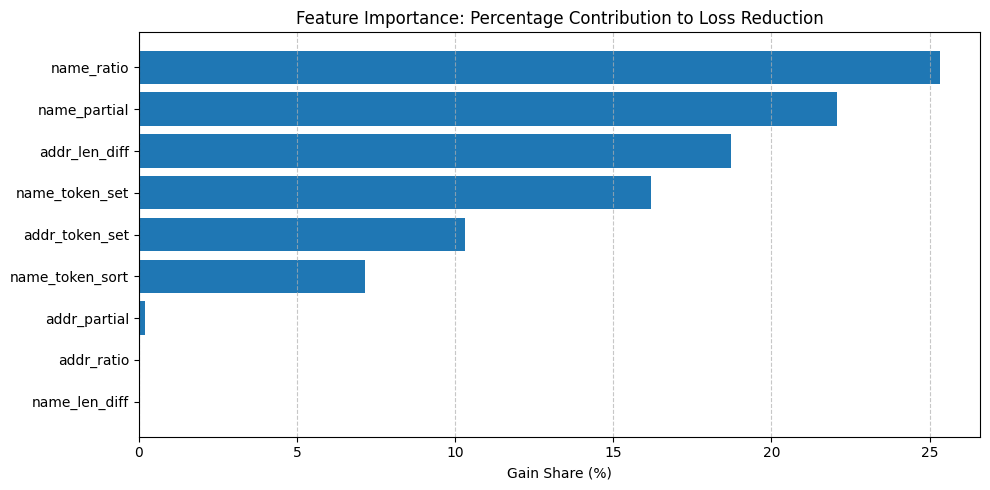

In [7]:
importance_gain = model.booster_.feature_importance(importance_type="gain")
importance_split = model.booster_.feature_importance(importance_type="split")

fi_df = pd.DataFrame({
    "Feature": FEATURE_COLS,
    "Gain (Total Loss Reduction)": importance_gain,
    "Split Count (Branch Frequency)": importance_split
}).sort_values(by="Gain (Total Loss Reduction)", ascending=False).reset_index(drop=True)

# Relative percentage contribution
fi_df["Gain Share (%)"] = (fi_df["Gain (Total Loss Reduction)"] / fi_df["Gain (Total Loss Reduction)"].sum() * 100).round(2)

print("=" * 75)
print(f"{'LIGHTGBM FEATURE IMPORTANCE RANKING':^75}")
print("=" * 75)
display(fi_df)

# Visual Bar Chart
plt.figure(figsize=(10, 5))
plt.barh(fi_df["Feature"][::-1], fi_df["Gain Share (%)"][::-1], color="#1f77b4")
plt.xlabel("Gain Share (%)")
plt.title("Feature Importance: Percentage Contribution to Loss Reduction")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

## Save Model Artifact to Central S3 Bucket

In [8]:
import s3fs

local_model_path = "/tmp/lgbm_model_latest.pkl"

# 1. Save locally using joblib
joblib.dump(model, local_model_path)
file_size_mb = os.path.getsize(local_model_path) / (1024 * 1024)
print(f"📦 Serialized model locally: {local_model_path} ({file_size_mb:.2f} MB)")

# 2. Upload directly to central S3 models/ folder
print(f"⏳ Uploading model artifact to S3: {MODEL_CHECKPOINT_S3} ...")
fs = s3fs.S3FileSystem(**s3_storage_options)

bucket_name = S3_BUCKET.replace("s3://", "").strip("/")
s3_target_key = f"{bucket_name}/models/lgbm_model_latest.pkl"

fs.put(local_model_path, s3_target_key)

# Verify existence
if fs.exists(s3_target_key):
    s3_info = fs.info(s3_target_key)
    print(f"🎉 Model checkpoint successfully uploaded to S3!")
    print(f"   • Path: s3://{s3_target_key}")
    print(f"   • Size: {s3_info['size'] / (1024*1024):.2f} MB")
else:
    raise RuntimeError("Model upload verification failed!")

📦 Serialized model locally: /tmp/lgbm_model_latest.pkl (0.01 MB)
⏳ Uploading model artifact to S3: s3://amz-ml-crazy-dave-bucket-177683310295-us-east-1-an/models/lgbm_model_latest.pkl ...
🎉 Model checkpoint successfully uploaded to S3!
   • Path: s3://amz-ml-crazy-dave-bucket-177683310295-us-east-1-an/models/lgbm_model_latest.pkl
   • Size: 0.01 MB
